# Day 4 — Cost-based threshold + explainability

Two things happen here, and after this the holdout is **locked** — not touched again for the classifier:

1. Replace the arbitrary 0.5 cutoff with a threshold chosen to minimize real ₹ cost.
2. Use SHAP to see *why* the model flags what it flags — the beginning of the plain-English reasons the case-queue product will show an analyst.

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

from src.data import load_merged_train
from src.features import get_feature_lists
from src.split import apply_locked_split
from src.cost import total_cost, find_optimal_threshold, DEFAULT_REVIEW_COST

RANDOM_STATE = 42

In [2]:
train_full = load_merged_train()
train_df, holdout_df = apply_locked_split(train_full)
numeric_features, categorical_features = get_feature_lists(train_full)

X_holdout = holdout_df[numeric_features + categorical_features]
y_holdout = holdout_df['isFraud']
amounts_holdout = holdout_df['TransactionAmt']

model = joblib.load('../models/classifier_v2.joblib')
y_proba = model.predict_proba(X_holdout)[:, 1]
print('Loaded model, scored', len(X_holdout), 'holdout transactions.')

Loaded model, scored 118108 holdout transactions.


## 1. Cost-based threshold selection

**Cost assumptions (stated explicitly, not hidden):**

- **Cost of a false negative (missed fraud) = the transaction's own amount.** If fraud goes undetected, the merchant loses that transaction's value. This follows standard cost-sensitive fraud-detection practice (e.g. cost-matrix approaches in credit-card fraud research), rather than a flat penalty — a missed ₹50,000 fraud is treated as worse than a missed ₹200 one.
- **Cost of a false positive (unnecessary manual review) = ₹100 per case.** Estimated from roughly 10–15 minutes of a fraud-ops analyst's time at a typical blended cost of ₹400–600/hour for a lightweight per-transaction check (not a full investigation).
- **Currency caveat:** the IEEE-CIS dataset's `TransactionAmt` field is originally denominated in USD. For this exercise we treat its numeric value directly as ₹ at risk — what matters for *selecting a threshold* is the ratio between the two costs, not the absolute currency. A real deployment would substitute the merchant's actual currency and order values.

In [3]:
best_threshold, best_cost, cost_curve = find_optimal_threshold(
    y_holdout, y_proba, amounts_holdout, review_cost=DEFAULT_REVIEW_COST
)

cost_at_default = total_cost(y_holdout, y_proba, amounts_holdout, threshold=0.5, review_cost=DEFAULT_REVIEW_COST)

print(f'Cost-optimal threshold: {best_threshold:.2f}')
print(f'Total cost at optimal threshold: Rs {best_cost:,.0f}')
print(f'Total cost at default 0.5 threshold: Rs {cost_at_default:,.0f}')
print(f'Saving vs default threshold: Rs {cost_at_default - best_cost:,.0f}')

Cost-optimal threshold: 0.88
Total cost at optimal threshold: Rs 387,932
Total cost at default 0.5 threshold: Rs 1,023,980
Saving vs default threshold: Rs 636,047


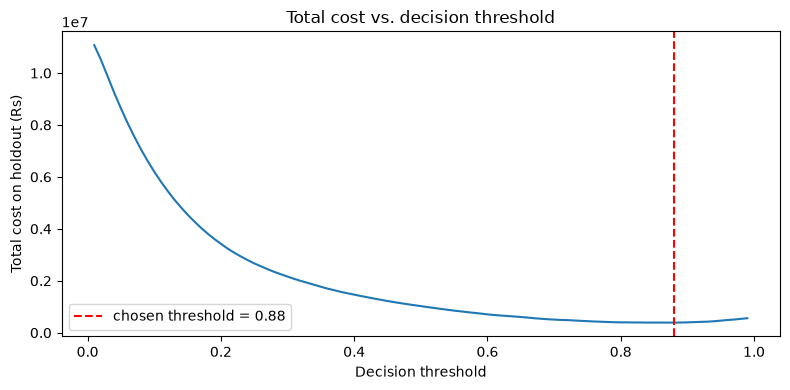

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_curve['threshold'], cost_curve['total_cost'])
ax.axvline(best_threshold, color='red', linestyle='--', label=f'chosen threshold = {best_threshold:.2f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Total cost on holdout (Rs)')
ax.set_title('Total cost vs. decision threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Final locked classifier results

Evaluated at the cost-optimal threshold. **This is the final classifier result — the holdout is not touched again after this notebook.**

In [5]:
y_pred_final = (y_proba >= best_threshold).astype(int)

precision = precision_score(y_holdout, y_pred_final)
recall = recall_score(y_holdout, y_pred_final)
f1 = f1_score(y_holdout, y_pred_final)
cm = confusion_matrix(y_holdout, y_pred_final)

tn, fp, fn, tp = cm.ravel()
reviews_per_fraud_caught = fp / tp if tp > 0 else float('inf')

print(f'Threshold:  {best_threshold:.2f}')
print(f'Precision:  {precision:.4f}')
print(f'Recall:     {recall:.4f}')
print(f'F1:         {f1:.4f}')
print(f'Manual reviews needed per real fraud caught: {reviews_per_fraud_caught:.2f}')
print()
print(classification_report(y_holdout, y_pred_final, target_names=['not fraud', 'fraud']))
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm)

Threshold:  0.88
Precision:  0.8045
Recall:     0.5376
F1:         0.6445
Manual reviews needed per real fraud caught: 0.24

              precision    recall  f1-score   support

   not fraud       0.98      1.00      0.99    113975
       fraud       0.80      0.54      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.89      0.77      0.82    118108
weighted avg       0.98      0.98      0.98    118108

Confusion matrix (rows=actual, cols=predicted):
[[113435    540]
 [  1911   2222]]


## 3. Explainability: SHAP

SHAP explains individual predictions by attributing the model's output to each input feature — e.g. "this transaction was flagged mainly because of X and Y." Computed on a random sample of the holdout (SHAP is exact but relatively expensive to run on the full 118K rows).

In [6]:
sample = X_holdout.sample(n=3000, random_state=RANDOM_STATE)

preprocessor = model.named_steps['prep']
classifier = model.named_steps['clf']

sample_transformed = preprocessor.transform(sample)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(sample_transformed)

# LightGBM binary classifier: use the positive-class SHAP values if returned as a list.
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print('SHAP values computed for', sample_transformed.shape[0], 'transactions,', sample_transformed.shape[1], 'features.')

SHAP values computed for 3000 transactions, 555 features.


C:\Users\singa\Projects\ai-risk-manager\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Top 20 features driving fraud predictions:
num__TransactionAmt    0.258806
num__C13               0.242162
num__C14               0.189044
num__V70               0.182061
num__card2             0.150996
cat__ProductCD_R       0.147855
num__card1             0.143635
num__C1                0.142209
cat__card6_credit      0.128936
num__C11               0.113951
num__D1                0.106471
num__D4                0.097469
num__V294              0.093217
num__addr1             0.085149
num__D15               0.080923
num__V91               0.080446
num__card5             0.078993
num__V258              0.078572
num__D3                0.077695
num__V48               0.074147
dtype: float64


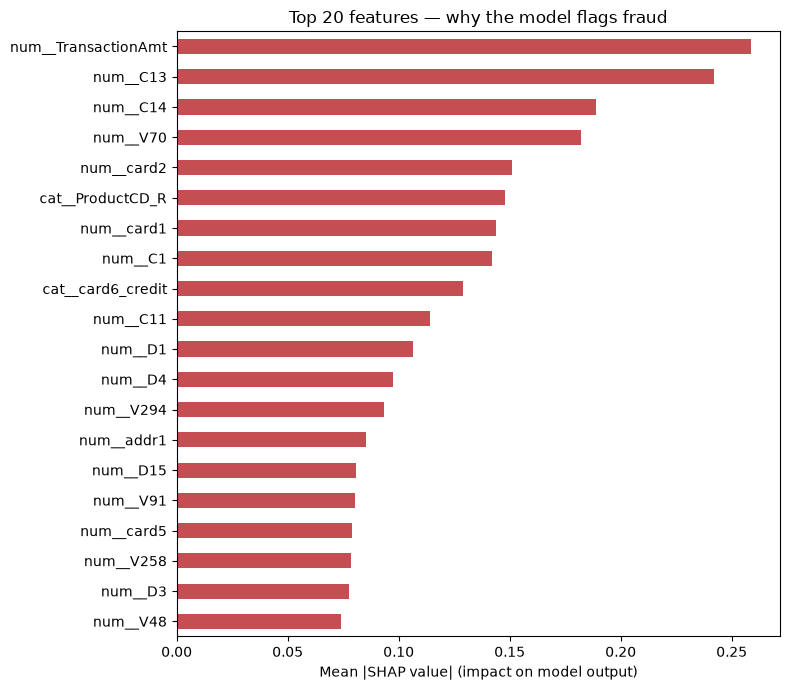

In [7]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

top_20 = importance.head(20)
print('Top 20 features driving fraud predictions:')
print(top_20)

fig, ax = plt.subplots(figsize=(8, 7))
top_20[::-1].plot(kind='barh', ax=ax, color='#C44E52')
ax.set_xlabel('Mean |SHAP value| (impact on model output)')
ax.set_title('Top 20 features — why the model flags fraud')
plt.tight_layout()
plt.show()

## Save final locked results

In [8]:
final_metrics = {
    'model': 'LightGBM (class_weight=balanced), cost-optimal threshold',
    'threshold': best_threshold,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'confusion_matrix': cm.tolist(),
    'reviews_per_fraud_caught': reviews_per_fraud_caught,
    'total_cost_rs': best_cost,
    'total_cost_at_default_threshold_rs': cost_at_default,
    'cost_assumptions': {
        'false_negative_cost': 'transaction amount (TransactionAmt)',
        'false_positive_cost_rs': DEFAULT_REVIEW_COST,
    },
    'top_shap_features': top_20.to_dict(),
    'n_holdout': len(X_holdout),
    'locked': True,
}

with open('../results/classifier_final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print('Saved locked final results to results/classifier_final_metrics.json')
print('Holdout is now locked for the classifier — not evaluated again.')

Saved locked final results to results/classifier_final_metrics.json
Holdout is now locked for the classifier — not evaluated again.


## Takeaway

_Fill in after running: the chosen threshold, how precision/recall look at that threshold vs. the default 0.5, the ₹ cost saved, and the top 3-5 SHAP features in plain English._